In [1]:
%cd /home/ytee/test/trade_bot/
import os
print(os.getcwd())
import numpy as np
from src.csv.cftc import CFTC
from src.pattern.correlation import CORR3
c = CFTC()
c3 = CORR3()

/home/ytee/test/trade_bot
/home/ytee/test/trade_bot


/home/ytee/test/trade_bot/venv/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
cftc_original = c.get_all_data()

df = cftc_original.copy()
headers= ['ccy', 'dt']
features = ['open_interest_all',
       'noncomm_positions_long_all', 'noncomm_positions_short_all',
       'noncomm_postions_spread_all', 'comm_positions_long_all',
       'comm_positions_short_all', 'nonrept_positions_long_all',
       'nonrept_positions_short_all', 'traders_noncomm_long_all',
       'traders_noncomm_short_all', 'traders_noncomm_spread_all',
       'traders_comm_long_all', 'traders_comm_short_all',
       'conc_gross_le_4_tdr_long', 'conc_gross_le_4_tdr_short',
       'conc_gross_le_8_tdr_long', 'conc_gross_le_8_tdr_short',
       'conc_net_le_4_tdr_long_all', 'conc_net_le_4_tdr_short_all',
       'conc_net_le_8_tdr_long_all', 'conc_net_le_8_tdr_short_all',]

zero_counts = (cftc_original[features].astype('float') <= 0 ).sum()
feature_no_zero = zero_counts[zero_counts ==0].index.tolist()
feature_no_zero = ['open_interest_all'] + [ x for x in features if 'conc_' in x ]

df = df[headers + feature_no_zero]
df = df.sort_values(['ccy', 'dt'])
df[feature_no_zero] = df[feature_no_zero].astype(float)

log_feat = [ x for x in feature_no_zero if  not 'conc' in x]

# Compute log-differences per ccy
df[log_feat] = df.groupby('ccy')[log_feat].transform(lambda g: np.log(g / g.shift(1)))
df


,ccy,dt,open_interest_all,conc_gross_le_4_tdr_long,conc_gross_le_4_tdr_short,conc_gross_le_8_tdr_long,conc_gross_le_8_tdr_short,conc_net_le_4_tdr_long_all,conc_net_le_4_tdr_short_all,conc_net_le_8_tdr_long_all,conc_net_le_8_tdr_short_all
163,AUD,1987-01-30,NaN,59.4,29.9,59.4,29.9,59.4,29.9,59.4,29.9
213,AUD,1987-05-29,0.165685,42.7,27.4,42.7,27.4,42.7,27.4,42.7,27.4
234,AUD,1987-07-31,0.742153,64.6,65.4,64.6,65.4,64.6,65.4,64.6,65.4
245,AUD,1987-08-14,0.004771,64.3,65.7,64.3,70.5,64.3,65.7,64.3,70.5
248,AUD,1987-08-31,-0.014382,65.2,74.4,65.2,79.3,65.2,74.4,65.2,79.3
...,...,...,...,...,...,...,...,...,...,...,...
19486,XAU,2025-06-10,0.002886,20.3,31.9,31.6,51.5,17.5,30.6,27.4,47.6
19489,XAU,2025-06-17,0.056101,19.5,31.5,30.8,51.2,16.8,30.5,26.2,47.9
19509,XAU,2025-06-24,-0.014281,20.0,31.3,31.3,51.3,17.3,30.4,27.0,47.7
19518,XAU,2025-07-01,0.006197,20.1,31.1,31.1,50.6,17.4,30.3,26.4,47.3


In [3]:
import pandas as pd
ccy = c3.df.copy()

ccy['dt'] = pd.to_datetime(c3.df.index)
ccy.set_index('dt', drop=True, inplace=True)
weekly_close = ccy.resample('W-TUE').last()

weekly_logret  = np.log(weekly_close / weekly_close.shift(1))
ccy2 = weekly_logret.stack().reset_index()
ccy2.columns = ['dt', 'ccy', 'close']
ccy2
# weekly_close.stack().reset_index()

,dt,ccy,close
0,1999-01-12,AUD,0.028749
1,1999-01-12,JPY,-0.012402
2,1999-01-12,USD,-0.003335
3,1999-01-12,GBP,-0.020601
4,1999-01-12,CAD,0.005231
...,...,...,...
15021,2025-03-25,EUR,-0.001561
15022,2025-03-25,XAU,0.014177
15023,2025-03-25,XAG,-0.018913
15024,2025-03-25,OIL,0.027349


In [4]:
ccym = ccy2.merge(df, on=headers, how='inner')

ccym.columns

Index(['dt', 'ccy', 'close', 'open_interest_all', 'conc_gross_le_4_tdr_long',
       'conc_gross_le_4_tdr_short', 'conc_gross_le_8_tdr_long',
       'conc_gross_le_8_tdr_short', 'conc_net_le_4_tdr_long_all',
       'conc_net_le_4_tdr_short_all', 'conc_net_le_8_tdr_long_all',
       'conc_net_le_8_tdr_short_all'],
      dtype='object')

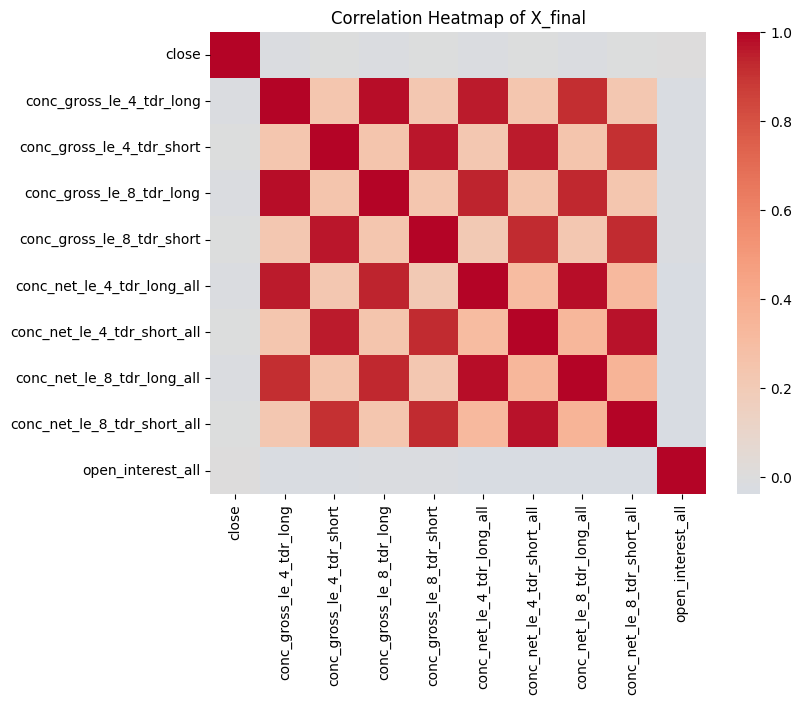

In [5]:


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(ccym[ccym.columns.difference(['dt', 'ccy'])].corr(), cmap='coolwarm', annot=False, fmt=".2f", center=0)
plt.title("Correlation Heatmap of X_final")
# plt.tight_layout()
plt.show()


Index(['dt', 'ccy', 'close', 'open_interest_all', 'conc_gross_le_4_tdr_long',
       'conc_gross_le_4_tdr_short', 'conc_gross_le_8_tdr_long',
       'conc_gross_le_8_tdr_short', 'conc_net_le_4_tdr_long_all',
       'conc_net_le_4_tdr_short_all', 'conc_net_le_8_tdr_long_all',
       'conc_net_le_8_tdr_short_all'],
      dtype='object')


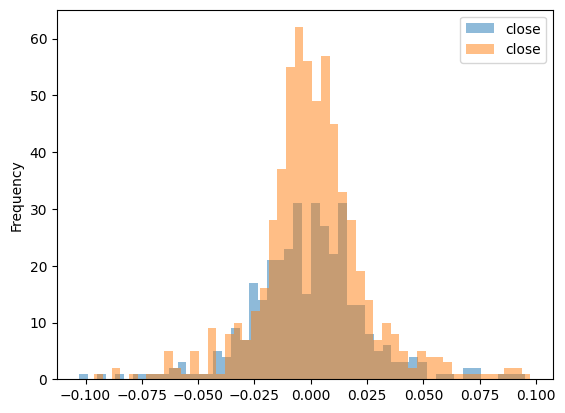

In [10]:
feat = 'open_interest_all'
low, high = ccym[feat].quantile([0.01, 0.99])
ccym_filtered = ccym[(ccym[feat] >= low) & (ccym[feat] <= high)]

# ax = ccym_filtered[feat].plot(kind='hist', bins=50)
print(ccym.columns)
low, high = ccym['close'].quantile([0.01, 0.99])
ccym_filtered = ccym[(ccym['close'] >= low) & (ccym['close'] <= high)]

ax = ccym_filtered[ccym_filtered[feat] > 0.2].close.plot(kind='hist', bins=50, alpha=0.5)
ccym_filtered[ccym_filtered[feat] < -0.2].close.plot(kind='hist', bins=50, alpha=0.5)

ax.legend()

Index(['dt', 'ccy', 'close', 'open_interest_all', 'conc_gross_le_4_tdr_long',
       'conc_gross_le_4_tdr_short', 'conc_gross_le_8_tdr_long',
       'conc_gross_le_8_tdr_short', 'conc_net_le_4_tdr_long_all',
       'conc_net_le_4_tdr_short_all', 'conc_net_le_8_tdr_long_all',
       'conc_net_le_8_tdr_short_all'],
      dtype='object')


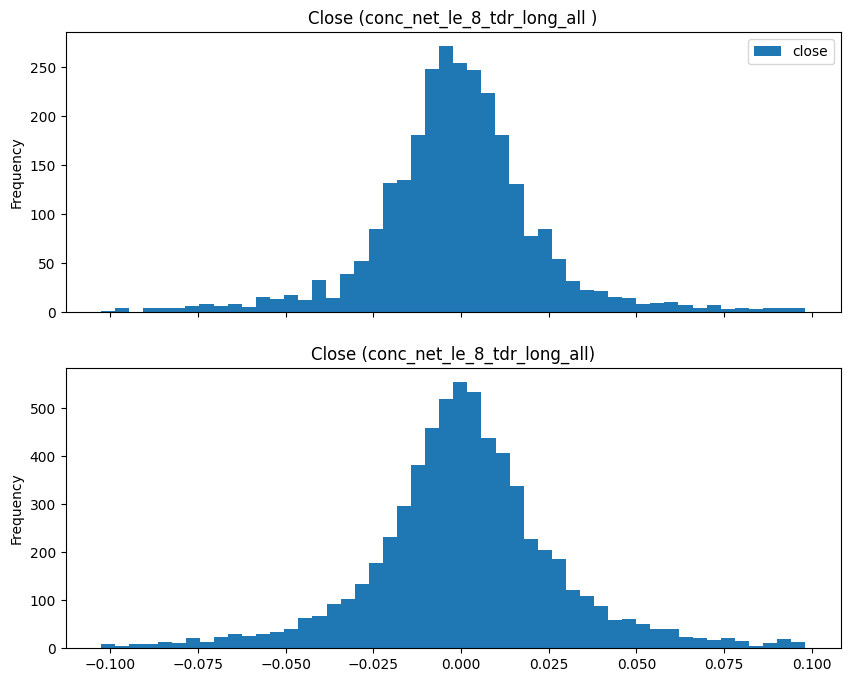

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)

feat = 'conc_net_le_8_tdr_long_all'
low, high = ccym[feat].quantile([0.01, 0.99])
ccym_filtered = ccym[(ccym[feat] >= low) & (ccym[feat] <= high)]

# ax = ccym_filtered[feat].plot(kind='hist', bins=50)
print(ccym.columns)
low, high = ccym['close'].quantile([0.01, 0.99])
ccym_filtered = ccym[(ccym['close'] >= low) & (ccym['close'] <= high)]



ax = ccym_filtered[ccym_filtered[feat] > 60].close.plot(kind='hist', bins=50, ax=axes[0], title=f'Close ({feat} )')
ccym_filtered[ccym_filtered[feat] < 40].close.plot(kind='hist', bins=50, ax=axes[1], title=f'Close ({feat})')

ax.legend()